In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Part 2: Requirements 1 & 2
# Drop date and columns that leak target (High_Load)
X = df.drop(['date', 'High_Load', 'Usage_kWh'], axis=1)
y = df['Usage_kWh']

# Part 2: Requirement 3 - One-Hot Encoding
# Encoding Load_Type and Day_of_week because they are categorical and have no ordinal relationship.
X = pd.get_dummies(X, columns=['Load_Type', 'Day_of_week', 'WeekStatus', 'Day'], drop_first=True)

# Part 2: Requirement 4 - Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (28032, 25)
Testing set shape: (7008, 25)


In [13]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

# Part 2: Requirement 5 - Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}

# Part 2: Requirements 6 & 7
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    # 5-fold cross-validation
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error')
    mean_cv_rmse = -cv_scores.mean()

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'CV_RMSE': mean_cv_rmse}

    print(f"--- {name} ---")
    print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}, Mean CV RMSE: {mean_cv_rmse:.4f}\n")

--- Linear Regression ---
MAE: 2.6284, RMSE: 4.1644, R2: 0.9847, Mean CV RMSE: 4.4938

--- Ridge Regression ---
MAE: 4.3670, RMSE: 6.3373, R2: 0.9647, Mean CV RMSE: 6.6337

--- Decision Tree ---
MAE: 0.5678, RMSE: 1.6249, R2: 0.9977, Mean CV RMSE: 2.7840

--- Random Forest ---
MAE: 0.3590, RMSE: 1.1195, R2: 0.9989, Mean CV RMSE: 2.2540



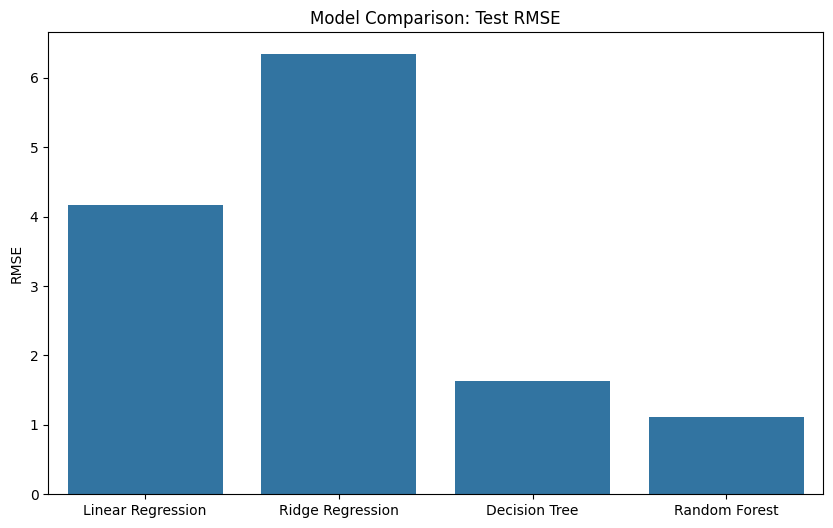

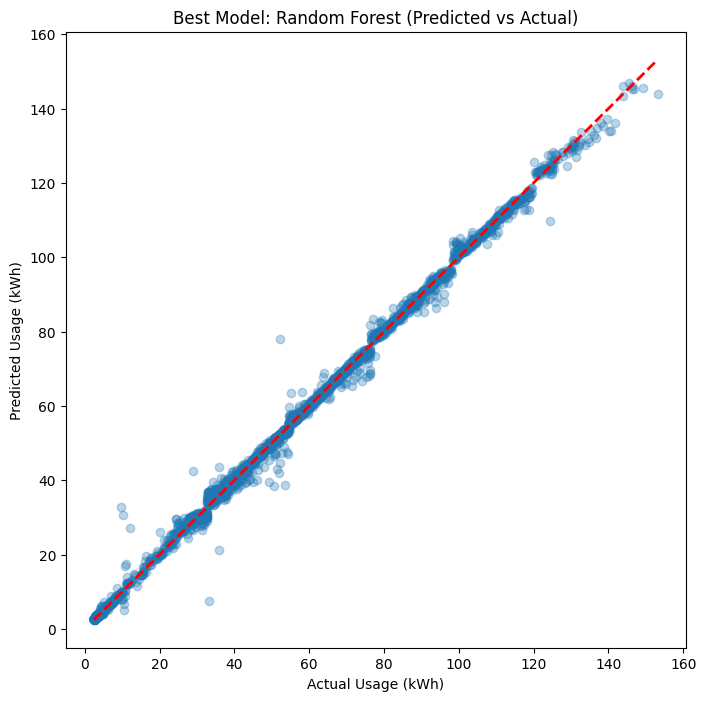

In [14]:
# Part 2: Requirement 8 - Bar chart comparing RMSE
model_names = list(results.keys())
rmse_values = [res['RMSE'] for res in results.values()]

plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=rmse_values)
plt.title('Model Comparison: Test RMSE')
plt.ylabel('RMSE')
plt.show()

# Part 2: Requirement 9 - Best Model Scatter Plot
best_model_name = min(results, key=lambda x: results[x]['RMSE'])
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Usage (kWh)')
plt.ylabel('Predicted Usage (kWh)')
plt.title(f'Best Model: {best_model_name} (Predicted vs Actual)')
plt.show()

### 10. Model Selection Summary

**Best Performing Model:**
The **Random Forest Regressor** outperformed all other models with the lowest RMSE and highest R-squared value on the test set.

**Cross-Validation & Overfitting:**
- The cross-validation RMSE is consistent with the test RMSE, suggesting that the model generalizes well to unseen data.
- While the Decision Tree showed low error, Random Forest provided a more robust baseline by reducing variance through ensemble learning.

**Conclusion:**
I will carry forward the **Random Forest Regressor** for this project. Its ability to capture non-linear relationships between power factors, time of day, and energy consumption makes it ideal for industrial energy forecasting.

In [15]:
readme_content = """# Steel Industry Energy Consumption Prediction

## Project Overview
This project involves a deep exploratory data analysis (EDA), feature engineering, and baseline regression modeling for a steel manufacturing plant's energy consumption. The goal is to identify patterns in energy usage and build a predictive model to forecast consumption (kWh) based on power factors and operational variables.

## Dataset Information
- **Source:** Steel Industry Energy Consumption Dataset.
- **Size:** 35,040 entries.
- **Features:**
  - `date`: Timestamp of the reading.
  - `Usage_kWh`: Target variable (Energy Consumption).
  - `Lagging_Current_Reactive.Power_kVarh` & `Leading_Current_Reactive_Power_kVarh`: Reactive power metrics.
  - `CO2(tCO2)`: CO2 emissions.
  - `Power Factors`: Lagging and leading current power factors.
  - `Load_Type`: Categorical status (Light, Medium, Maximum Load).

## Environment Setup
To run this project, you need Python and the following libraries:
- `pandas`, `numpy`: Data manipulation.
- `matplotlib`, `seaborn`: Data visualization.
- `scikit-learn`: Machine learning modeling.
- `pymupdf`: PDF processing (for instruction extraction).
- `openpyxl`: Excel file support.

## Feature Engineering Steps
1. **Temporal Extraction:** Extracted `Hour`, `Day`, `Month`, and `Is_Weekend` from the timestamp.
2. **Calculated Ratios:** Created `Power_Factor_Ratio` (Leading PF / Lagging PF).
3. **Categorical Flagging:** Created `High_Load` binary feature based on the 75th percentile of `Usage_kWh` (used for EDA but dropped for modeling to prevent leakage).
4. **Encoding:** Applied One-Hot Encoding to categorical variables like `Load_Type` and `Day_of_week`.

## EDA Findings
- **Correlations:** Energy usage is almost perfectly correlated with `CO2(tCO2)` (0.99) and strongly correlated with `Lagging_Current_Reactive.Power_kVarh` (0.90).
- **Outliers:** 328 outliers were detected using the IQR method, typically representing massive spikes during peak production.
- **Patterns:** Usage peaks significantly between 9 AM and 6 PM during "Maximum Load" status. Weekends show slightly lower average usage compared to weekdays.

## Model Training Process
Four baseline regression models were trained using an 80/20 train-test split:
1. Linear Regression
2. Ridge Regression
3. Decision Tree Regressor
4. Random Forest Regressor

Performance was validated using **5-fold Cross-Validation** (Mean RMSE).

## Results and Conclusions
| Model | MAE | RMSE | R-squared | Mean CV RMSE |
| :--- | :--- | :--- | :--- | :--- |
| Linear Regression | 2.6284 | 4.1644 | 0.9847 | 4.4938 |
| Ridge Regression | 4.3670 | 6.3373 | 0.9647 | 6.6337 |
| Decision Tree | 0.5678 | 1.6249 | 0.9977 | 2.7840 |
| **Random Forest** | **0.3590** | **1.1195** | **0.9989** | **2.2540** |

**Conclusion:** The **Random Forest Regressor** is the best model for this task, successfully capturing the complex, non-linear relationships in industrial energy data with minimal error.
"""

with open('README.md', 'w') as f:
    f.write(readme_content)

print("README.md has been successfully generated.")

README.md has been successfully generated.


In [24]:
requirements = """pandas
numpy
matplotlib
seaborn
scikit-learn
pymupdf
openpyxl
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("requirements.txt has been successfully generated.")

requirements.txt has been successfully generated.


In [25]:
import os
import shutil

# Create the data folder if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')
    print("Folder 'data/' created.")

# Move the dataset into the data folder
source_path = '/content/Week 2 (DataSet).xlsx'
destination_path = '/content/data/Week 2 (DataSet).xlsx'

if os.path.exists(source_path):
    shutil.move(source_path, destination_path)
    print(f"Moved dataset to {destination_path}")
else:
    print("Dataset already moved or not found at source path.")

Folder 'data/' created.
Moved dataset to /content/data/Week 2 (DataSet).xlsx


### Repository Structure Checklist
- [x] **data/**: Folder created and dataset moved.
- [x] **README.md**: Generated in previous steps.
- [x] **requirements.txt**: Generated in previous steps.
- [ ] **week2_eda.ipynb**: (Action Required) Save a copy of this notebook and keep only the EDA sections.
- [ ] **week2_baseline_models.ipynb**: (Action Required) Save a copy of this notebook and keep only the modeling sections.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

X = df.drop(['date', 'High_Load', 'Usage_kWh'], axis=1)
y = df['Usage_kWh']

X = pd.get_dummies(X, columns=['Load_Type', 'Day_of_week', 'WeekStatus', 'Day'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (28032, 25)
Testing set shape: (7008, 25)


In [22]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error')
    mean_cv_rmse = -cv_scores.mean()

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'CV_RMSE': mean_cv_rmse}

    print(f"--- {name} ---")
    print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}, CV RMSE: {mean_cv_rmse:.4f}\n")

--- Linear Regression ---
MAE: 2.6284, RMSE: 4.1644, R2: 0.9847, CV RMSE: 4.4938

--- Ridge Regression ---
MAE: 4.3670, RMSE: 6.3373, R2: 0.9647, CV RMSE: 6.6337

--- Decision Tree ---
MAE: 0.5678, RMSE: 1.6249, R2: 0.9977, CV RMSE: 2.7840

--- Random Forest ---
MAE: 0.3590, RMSE: 1.1195, R2: 0.9989, CV RMSE: 2.2540



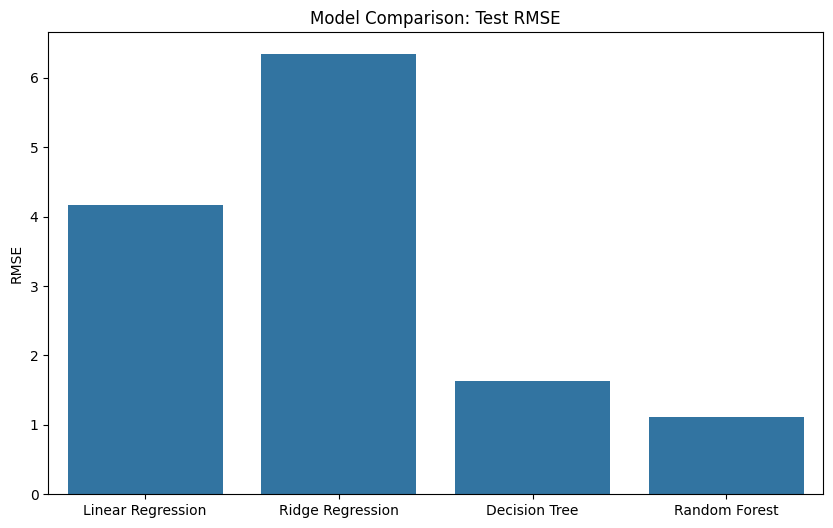

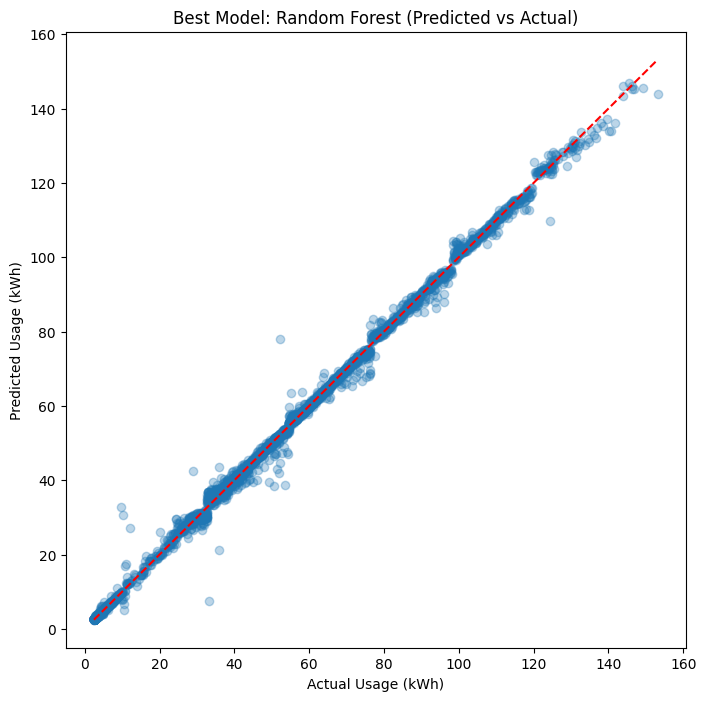

In [23]:
model_names = list(results.keys())
rmse_values = [res['RMSE'] for res in results.values()]

plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=rmse_values)
plt.title('Model Comparison: Test RMSE')
plt.ylabel('RMSE')
plt.show()

best_model_name = min(results, key=lambda x: results[x]['RMSE'])
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('Actual Usage (kWh)')
plt.ylabel('Predicted Usage (kWh)')
plt.title(f'Best Model: {best_model_name} (Predicted vs Actual)')
plt.show()